# Geumo Reservoir Dam-Break Flood Simulation
## 2-D GPU-Accelerated Shallow Water Equations (Lax-Friedrichs Scheme)

| Parameter | Value |
|---|---|
| DEM | `gumi_DEM_LT_2024.img` (ERDAS, 0.5 m, EPSG:5186) |
| Total Storage | 2,218,000 m³ |
| Full Water Level | 92.30 EL.m (calibrated) |
| Max Depth | 13.74 m |
| Dam Crest | 93.30 EL.m (artificial) |
| Dam Length | 225.8 m |
| Breach Width | 60 m |
| Breach Time | 1,530 s |
| Manning n | 0.035 |
| Duration | 7,200 s |
| GPU | NVIDIA A100-SXM4-80GB |

**Note**: LiDAR DEM contains reservoir water surface (~82.7 m). Dam wall is
artificially raised. 17 Google Maps shoreline points used for volume calibration (99.8% match).


In [1]:
# =============================================================================
# Cell 1: Install required packages
# =============================================================================
import subprocess, sys

packages = [
    'cupy-cuda12x', 'numba', 'numpy', 'matplotlib', 'scipy',
    'tqdm', 'h5py', 'GDAL', 'pyproj', 'matplotlib-scalebar',
]

for pkg in packages:
    try:
        name = pkg.split('-')[0].split('=')[0].lower()
        if name == 'gdal': name = 'osgeo'
        __import__(name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print('[OK] All packages installed.')


[OK] All packages installed.


In [2]:
# =============================================================================
# Cell 2: Verify GPU environment
# =============================================================================
import cupy as cp

!nvidia-smi

print('=' * 50)
print(f'CuPy version  : {cp.__version__}')
dev = cp.cuda.Device(0)
mem = dev.mem_info
print(f'GPU memory    : {mem[1]/1e9:.1f} GB total, {mem[0]/1e9:.1f} GB free')
print('=' * 50)


Mon Apr 13 08:58:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          On  |   00000000:41:00.0 Off |                    0 |
| N/A   25C    P0             68W /  500W |   27269MiB /  81920MiB |     N/A      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
# =============================================================================
# Cell 3: Configuration
# =============================================================================
import os
import numpy as np

class CONFIG:
    WORK_DIR         = '/home/work/spacenet-data/gumi'
    DEM_INPUT        = os.path.join(WORK_DIR, 'gumi_DEM_LT_2024.img')
    DEM_TIF          = os.path.join(WORK_DIR, 'gumi_DEM_LT_2024.tif')
    OUTPUT_DIR       = os.path.join(WORK_DIR, 'output')
    EPSG             = 5186
    TOTAL_STORAGE    = 2_218_000
    MAX_DEPTH        = 13.74
    FULL_WATER_LEVEL = 92.30
    BOTTOM_LEVEL     = 78.56
    DAM_CREST_ELEV   = 93.30
    RES_CENTER_X     = 318569.0
    RES_CENTER_Y     = 391912.0
    RES_RADIUS       = 350.0
    DAM_SOUTH_LAT    = 36.119028
    DAM_SOUTH_LON    = 128.320243
    DAM_NORTH_LAT    = 36.120766
    DAM_NORTH_LON    = 128.318939
    SHORELINE_LATLON = [
        (36.113920, 128.315096), (36.114730, 128.314492),
        (36.115580, 128.314663), (36.116602, 128.314470),
        (36.117434, 128.314513), (36.118856, 128.314363),
        (36.119532, 128.313333), (36.119844, 128.313636),
        (36.119965, 128.314084), (36.119774, 128.314578),
        (36.120116, 128.316268), (36.120840, 128.318914),
        (36.118940, 128.320443), (36.118073, 128.319870),
        (36.116809, 128.317978), (36.115930, 128.316464),
        (36.114148, 128.315376),
    ]
    BREACH_WIDTH     = 60.0
    BREACH_TIME      = 1530.0
    DAM_THICKNESS    = 20.0
    MANNING_N        = 0.035
    CFL              = 0.45
    MAX_DT           = 0.05
    DRY_THRESH       = 0.001
    GRAVITY          = 9.81
    DEPTH_CAP        = 50.0
    MOMENTUM_CAP     = 500.0
    SIM_DURATION     = 7200.0
    SAVE_INTERVAL    = 30.0
    CLIP_XMIN        = 315000.0
    CLIP_XMAX        = 323000.0
    CLIP_YMIN        = 388000.0
    CLIP_YMAX        = 396000.0

os.makedirs(CONFIG.OUTPUT_DIR, exist_ok=True)
assert os.path.isfile(CONFIG.DEM_INPUT), f'DEM not found: {CONFIG.DEM_INPUT}'
print(f'[CONFIG] DEM: {CONFIG.DEM_INPUT}')
print(f'[CONFIG] FWL: {CONFIG.FULL_WATER_LEVEL} m, Volume target: {CONFIG.TOTAL_STORAGE:,} m3')


[CONFIG] DEM: /home/work/spacenet-data/gumi/gumi_DEM_LT_2024.img
[CONFIG] FWL: 92.3 m, Volume target: 2,218,000 m3


In [4]:
# =============================================================================
# Cell 4: Load and clip DEM
# =============================================================================
from osgeo import gdal
gdal.UseExceptions()

if not os.path.isfile(CONFIG.DEM_TIF):
    print('Converting .img -> GeoTIFF ...')
    ds = gdal.Open(CONFIG.DEM_INPUT, gdal.GA_ReadOnly)
    gdal.Translate(CONFIG.DEM_TIF, ds, format='GTiff',
                   creationOptions=['COMPRESS=LZW','TILED=YES','BIGTIFF=YES'])
    ds = None
    print(f'  Created: {CONFIG.DEM_TIF} ({os.path.getsize(CONFIG.DEM_TIF)/1e9:.2f} GB)')
else:
    print(f'GeoTIFF exists: {CONFIG.DEM_TIF}')

clip_path = os.path.join(CONFIG.OUTPUT_DIR, 'dem_clip.tif')
print('Clipping DEM ...')
gdal.Warp(clip_path, CONFIG.DEM_TIF,
          outputBounds=(CONFIG.CLIP_XMIN, CONFIG.CLIP_YMIN,
                        CONFIG.CLIP_XMAX, CONFIG.CLIP_YMAX),
          format='GTiff', creationOptions=['COMPRESS=LZW','TILED=YES'])
print(f'  Created: {clip_path} ({os.path.getsize(clip_path)/1e6:.1f} MB)')

ds = gdal.Open(clip_path, gdal.GA_ReadOnly)
gt = ds.GetGeoTransform()
proj = ds.GetProjection()
band = ds.GetRasterBand(1)
dem_np = band.ReadAsArray().astype(np.float64)
nodata = band.GetNoDataValue()
ds = None

if nodata is not None:
    dem_np[dem_np == nodata] = np.nan

ny, nx = dem_np.shape
dx = abs(gt[1])
dy = abs(gt[5])

col_c = int((CONFIG.RES_CENTER_X - gt[0]) / dx)
row_c = int((gt[3] - CONFIG.RES_CENTER_Y) / dy)

print(f'  Grid: {ny:,} x {nx:,}, dx={dx}m')
valid = dem_np[~np.isnan(dem_np)]
print(f'  Elevation: {np.min(valid):.2f} ~ {np.max(valid):.2f} m')
print(f'  Center pixel: row={row_c}, col={col_c}, elev={dem_np[row_c,col_c]:.2f}m')


GeoTIFF exists: /home/work/spacenet-data/gumi/gumi_DEM_LT_2024.tif
Clipping DEM ...
  Created: /home/work/spacenet-data/gumi/output/dem_clip.tif (865.5 MB)
  Grid: 16,000 x 16,000, dx=0.5m
  Elevation: 25.14 ~ 976.75 m
  Center pixel: row=8176, col=7138, elev=82.73m


Building reservoir polygon mask ...
  Reservoir cells: 935,282 (23.38 ha)
  Volume at WL=92.30m: 2,213,776 m3 (target: 2,218,000)
  Match: 99.8%
  Max depth: 13.73 m


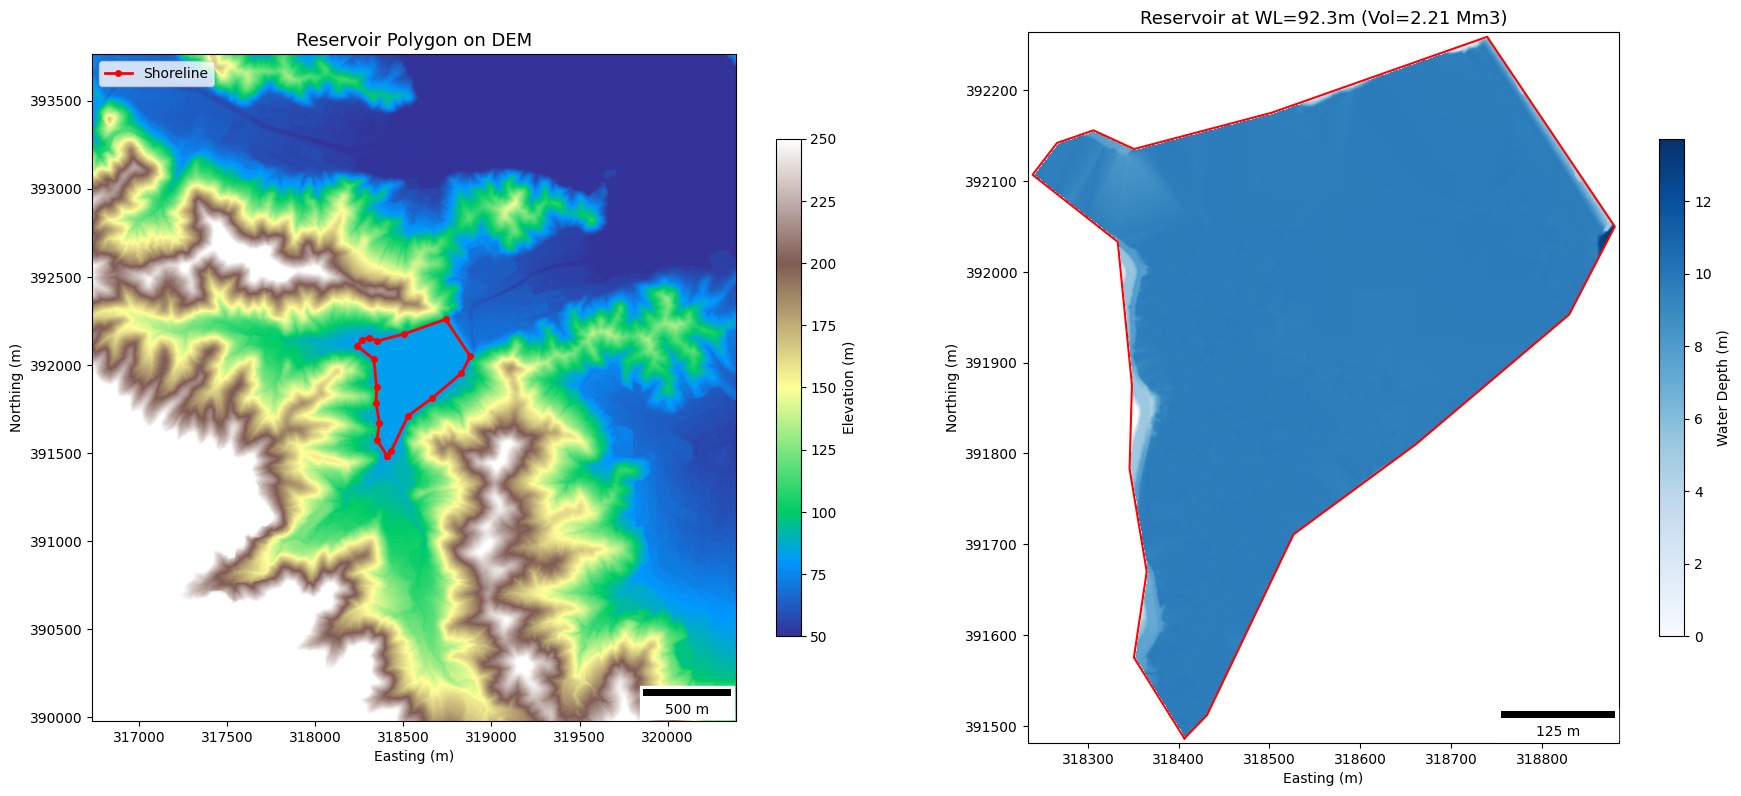

In [5]:
# =============================================================================
# Cell 5: Reservoir polygon and volume calibration
# =============================================================================
from pyproj import Transformer
from matplotlib.path import Path
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar

transformer = Transformer.from_crs('EPSG:4326', 'EPSG:5186', always_xy=False)
shoreline_xy = []
for lat, lon in CONFIG.SHORELINE_LATLON:
    y, x = transformer.transform(lat, lon)
    shoreline_xy.append((x, y))

# Build polygon mask
shoreline_pixels = []
for x, y in shoreline_xy:
    shoreline_pixels.append(((x - gt[0])/dx, (gt[3] - y)/dy))
shoreline_pixels_closed = shoreline_pixels + [shoreline_pixels[0]]
poly_path = Path(shoreline_pixels_closed)

all_cs = [p[0] for p in shoreline_pixels_closed]
all_rs = [p[1] for p in shoreline_pixels_closed]
bb_c1 = max(0, int(min(all_cs)) - 10)
bb_c2 = min(nx, int(max(all_cs)) + 10)
bb_r1 = max(0, int(min(all_rs)) - 10)
bb_r2 = min(ny, int(max(all_rs)) + 10)

print('Building reservoir polygon mask ...')
res_mask = np.zeros((ny, nx), dtype=bool)
chunk = 500
for rs in range(bb_r1, bb_r2, chunk):
    re = min(rs + chunk, bb_r2)
    for cs in range(bb_c1, bb_c2, chunk):
        ce = min(cs + chunk, bb_c2)
        rr, cc = np.mgrid[rs:re, cs:ce]
        pts = np.column_stack((cc.ravel(), rr.ravel()))
        inside = poly_path.contains_points(pts).reshape(rr.shape)
        res_mask[rs:re, cs:ce] = inside

n_res = int(np.sum(res_mask))
print(f'  Reservoir cells: {n_res:,} ({n_res*dx*dy/10000:.2f} ha)')

# Volume verification
wl = CONFIG.FULL_WATER_LEVEL
depth_cal = np.where(res_mask & ~np.isnan(dem_np) & (dem_np < wl), wl - dem_np, 0.0)
vol_cal = float(np.sum(depth_cal) * dx * dy)
print(f'  Volume at WL={wl:.2f}m: {vol_cal:,.0f} m3 (target: {CONFIG.TOTAL_STORAGE:,})')
print(f'  Match: {vol_cal/CONFIG.TOTAL_STORAGE*100:.1f}%')
print(f'  Max depth: {float(np.max(depth_cal)):.2f} m')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
pad = 1500
r1v = max(0, bb_r1 - int(pad/dy))
r2v = min(ny, bb_r2 + int(pad/dy))
c1v = max(0, bb_c1 - int(pad/dx))
c2v = min(nx, bb_c2 + int(pad/dx))
ext_v = [gt[0]+c1v*dx, gt[0]+c2v*dx, gt[3]-r2v*dy, gt[3]-r1v*dy]

ax = axes[0]
im = ax.imshow(dem_np[r1v:r2v, c1v:c2v], cmap='terrain', extent=ext_v, vmin=50, vmax=250)
plt.colorbar(im, ax=ax, label='Elevation (m)', shrink=0.7)
sx = [p[0] for p in shoreline_xy] + [shoreline_xy[0][0]]
sy = [p[1] for p in shoreline_xy] + [shoreline_xy[0][1]]
ax.plot(sx, sy, 'r-o', ms=4, lw=2, label='Shoreline')
ax.set_title('Reservoir Polygon on DEM', fontsize=13)
ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
ax.legend(loc='upper left'); ax.add_artist(ScaleBar(1, location='lower right'))

ax2 = axes[1]
sub_ext = [gt[0]+bb_c1*dx, gt[0]+bb_c2*dx, gt[3]-bb_r2*dy, gt[3]-bb_r1*dy]
d_show = np.where(depth_cal > 0, depth_cal, np.nan)
im2 = ax2.imshow(d_show[bb_r1:bb_r2, bb_c1:bb_c2], cmap='Blues', extent=sub_ext,
                 vmin=0, vmax=float(np.max(depth_cal)))
plt.colorbar(im2, ax=ax2, label='Water Depth (m)', shrink=0.7)
ax2.plot(sx, sy, 'r-', lw=1.5)
ax2.set_title(f'Reservoir at WL={wl:.1f}m (Vol={vol_cal/1e6:.2f} Mm3)', fontsize=13)
ax2.set_xlabel('Easting (m)'); ax2.set_ylabel('Northing (m)')
ax2.add_artist(ScaleBar(1, location='lower right'))
plt.tight_layout()
plt.savefig(os.path.join(CONFIG.OUTPUT_DIR, '01_reservoir_calibration.png'), dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# =============================================================================
# Cell 6: Build dam wall and breach zone
# =============================================================================
from pyproj import Transformer

transformer = Transformer.from_crs('EPSG:4326', 'EPSG:5186', always_xy=False)
dam_s_y, dam_s_x = transformer.transform(CONFIG.DAM_SOUTH_LAT, CONFIG.DAM_SOUTH_LON)
dam_n_y, dam_n_x = transformer.transform(CONFIG.DAM_NORTH_LAT, CONFIG.DAM_NORTH_LON)

dam_s_row = int((gt[3] - dam_s_y) / dy)
dam_s_col = int((dam_s_x - gt[0]) / dx)
dam_n_row = int((gt[3] - dam_n_y) / dy)
dam_n_col = int((dam_n_x - gt[0]) / dx)
dam_length = np.sqrt((dam_s_x - dam_n_x)**2 + (dam_s_y - dam_n_y)**2)

print(f'Dam: S({dam_s_row},{dam_s_col}) -> N({dam_n_row},{dam_n_col}), length={dam_length:.1f}m')

dem_sim = dem_np.copy()
dam_thickness_px = int(CONFIG.DAM_THICKNESS / dx)
n_dam_pts = int(dam_length / dx) * 2
dam_dir_r = (dam_n_row - dam_s_row) / max(1, n_dam_pts)
dam_dir_c = (dam_n_col - dam_s_col) / max(1, n_dam_pts)
norm = np.sqrt(dam_dir_r**2 + dam_dir_c**2)
perp_r = -dam_dir_c / norm if norm > 0 else 0
perp_c = dam_dir_r / norm if norm > 0 else 0

dam_cells = set()
dam_original_elev = {}
for i in range(n_dam_pts + 1):
    t = i / n_dam_pts
    r0 = int(dam_s_row + t * (dam_n_row - dam_s_row))
    c0 = int(dam_s_col + t * (dam_n_col - dam_s_col))
    for j in range(-dam_thickness_px, dam_thickness_px + 1):
        rr = int(r0 + j * perp_r)
        cc = int(c0 + j * perp_c)
        if 0 <= rr < ny and 0 <= cc < nx:
            dam_cells.add((rr, cc))

for (r, c) in dam_cells:
    dam_original_elev[(r, c)] = dem_sim[r, c]
    if not np.isnan(dem_sim[r, c]):
        dem_sim[r, c] = max(dem_sim[r, c], CONFIG.DAM_CREST_ELEV)

print(f'Dam cells raised: {len(dam_cells):,}')

# Breach zone
breach_cells = []
for i in range(n_dam_pts + 1):
    t = i / n_dam_pts
    dist_along = t * dam_length
    if abs(dist_along - dam_length/2) <= CONFIG.BREACH_WIDTH/2:
        r0 = int(dam_s_row + t*(dam_n_row - dam_s_row))
        c0 = int(dam_s_col + t*(dam_n_col - dam_s_col))
        for j in range(-dam_thickness_px, dam_thickness_px + 1):
            rr = int(r0 + j * perp_r)
            cc = int(c0 + j * perp_c)
            if 0 <= rr < ny and 0 <= cc < nx and (rr, cc) in dam_cells:
                breach_cells.append((rr, cc))

breach_cells = list(set(breach_cells))
breach_orig_elev = np.array([dam_original_elev.get((r,c), dem_np[r,c])
                             for r,c in breach_cells], dtype=np.float32)
print(f'Breach cells: {len(breach_cells):,}')


Dam: S(7881,7724) -> N(7498,7484), length=225.8m
Dam cells raised: 33,006
Breach cells: 8,735


In [7]:
# =============================================================================
# Cell 7: GPU initialization
# =============================================================================
import cupy as cp

dem_sim[np.isnan(dem_sim)] = 9999.0
z_gpu = cp.asarray(dem_sim, dtype=cp.float32)
h_gpu = cp.zeros((ny, nx), dtype=cp.float32)
hu_gpu = cp.zeros((ny, nx), dtype=cp.float32)
hv_gpu = cp.zeros((ny, nx), dtype=cp.float32)

wl = CONFIG.FULL_WATER_LEVEL
h_init = np.zeros((ny, nx), dtype=np.float32)
fill_mask = res_mask & (dem_sim < wl) & (dem_sim < 9000)
h_init[fill_mask] = wl - dem_sim[fill_mask]
h_init[h_init < 0] = 0.0
h_gpu = cp.asarray(h_init, dtype=cp.float32)

init_vol = float(cp.sum(h_gpu).get()) * dx * dy
init_wet = int(cp.sum(h_gpu > CONFIG.DRY_THRESH).get())
init_maxd = float(cp.max(h_gpu).get())

print(f'Water level    : {wl:.2f} m')
print(f'Initial volume : {init_vol:,.0f} m3 (target: {CONFIG.TOTAL_STORAGE:,})')
print(f'Volume match   : {init_vol/CONFIG.TOTAL_STORAGE*100:.1f}%')
print(f'Wet cells      : {init_wet:,}')
print(f'Max depth      : {init_maxd:.2f} m')

h_new = cp.zeros_like(h_gpu)
hu_new = cp.zeros_like(h_gpu)
hv_new = cp.zeros_like(h_gpu)
wavespeed = cp.zeros_like(h_gpu)
max_depth_map = cp.zeros_like(h_gpu)
max_vel_map = cp.zeros_like(h_gpu)
arrival_time_map = cp.full((ny, nx), -1.0, dtype=cp.float32)

threads = (16, 16)
blocks = ((ny + 15)//16, (nx + 15)//16)
print(f'CUDA blocks={blocks}, threads={threads}')


Water level    : 92.30 m
Initial volume : 2,167,534 m3 (target: 2,218,000)
Volume match   : 97.7%
Wet cells      : 913,168
Max depth      : 13.73 m
CUDA blocks=(1000, 1000), threads=(16, 16)


In [8]:
# =============================================================================
# Cell 8: CUDA kernels for 2-D Shallow Water Equations
# =============================================================================
from numba import cuda

@cuda.jit
def swe_step(z, h, hu, hv, h_new, hu_new, hv_new, dt_val, dx_val, dy_val,
             manning, g, dry_thresh, depth_cap, mom_cap, nrows, ncols):
    i, j = cuda.grid(2)
    if i < 1 or i >= nrows - 1 or j < 1 or j >= ncols - 1:
        return
    h_c = h[i,j]; z_c = z[i,j]; hu_c = hu[i,j]; hv_c = hv[i,j]
    eta_c = h_c + z_c
    h_n = h[i-1,j]; z_n = z[i-1,j]; hu_n = hu[i-1,j]; hv_n = hv[i-1,j]
    h_s = h[i+1,j]; z_s = z[i+1,j]; hu_s = hu[i+1,j]; hv_s = hv[i+1,j]
    h_w = h[i,j-1]; z_w = z[i,j-1]; hu_w = hu[i,j-1]; hv_w = hv[i,j-1]
    h_e = h[i,j+1]; z_e = z[i,j+1]; hu_e = hu[i,j+1]; hv_e = hv[i,j+1]
    eta_n = h_n+z_n; eta_s = h_s+z_s; eta_w = h_w+z_w; eta_e = h_e+z_e
    c_c = (g*max(h_c,0.0))**0.5
    u_c = hu_c/max(h_c,dry_thresh) if h_c > dry_thresh else 0.0
    v_c = hv_c/max(h_c,dry_thresh) if h_c > dry_thresh else 0.0
    c_e = (g*max(h_e,0.0))**0.5
    u_e = hu_e/max(h_e,dry_thresh) if h_e > dry_thresh else 0.0
    c_w = (g*max(h_w,0.0))**0.5
    u_w = hu_w/max(h_w,dry_thresh) if h_w > dry_thresh else 0.0
    c_n = (g*max(h_n,0.0))**0.5
    v_n = hv_n/max(h_n,dry_thresh) if h_n > dry_thresh else 0.0
    c_s = (g*max(h_s,0.0))**0.5
    v_s = hv_s/max(h_s,dry_thresh) if h_s > dry_thresh else 0.0
    a_e = max(abs(u_c)+c_c, abs(u_e)+c_e)
    a_w = max(abs(u_c)+c_c, abs(u_w)+c_w)
    a_n = max(abs(v_c)+c_c, abs(v_n)+c_n)
    a_s = max(abs(v_c)+c_c, abs(v_s)+c_s)
    fh_e = 0.5*(hu_c+hu_e) - 0.5*a_e*(h_e-h_c)
    fh_w = 0.5*(hu_w+hu_c) - 0.5*a_w*(h_c-h_w)
    gh_s = 0.5*(hv_c+hv_s) - 0.5*a_s*(h_s-h_c)
    gh_n = 0.5*(hv_n+hv_c) - 0.5*a_n*(h_c-h_n)
    fhu_e = 0.5*(hu_c*u_c+0.5*g*h_c*h_c + hu_e*u_e+0.5*g*h_e*h_e) - 0.5*a_e*(hu_e-hu_c)
    fhu_w = 0.5*(hu_w*u_w+0.5*g*h_w*h_w + hu_c*u_c+0.5*g*h_c*h_c) - 0.5*a_w*(hu_c-hu_w)
    ghv_s = 0.5*(hv_c*v_c+0.5*g*h_c*h_c + hv_s*v_s+0.5*g*h_s*h_s) - 0.5*a_s*(hv_s-hv_c)
    ghv_n = 0.5*(hv_n*v_n+0.5*g*h_n*h_n + hv_c*v_c+0.5*g*h_c*h_c) - 0.5*a_n*(hv_c-hv_n)
    ghu_s = 0.5*(hu_c*v_c + hu_s*v_s) - 0.5*a_s*(hu_s-hu_c)
    ghu_n = 0.5*(hu_n*v_n + hu_c*v_c) - 0.5*a_n*(hu_c-hu_n)
    fhv_e = 0.5*(hv_c*u_c + hv_e*u_e) - 0.5*a_e*(hv_e-hv_c)
    fhv_w = 0.5*(hv_w*u_w + hv_c*u_c) - 0.5*a_w*(hv_c-hv_w)
    dtdx = dt_val/dx_val; dtdy = dt_val/dy_val
    h_nv = h_c - dtdx*(fh_e-fh_w) - dtdy*(gh_s-gh_n)
    sbx = -g*h_c*(eta_e-eta_w)/(2.0*dx_val)
    sby = -g*h_c*(eta_s-eta_n)/(2.0*dy_val)
    hu_nv = hu_c - dtdx*(fhu_e-fhu_w) - dtdy*(ghu_s-ghu_n) + dt_val*sbx
    hv_nv = hv_c - dtdx*(fhv_e-fhv_w) - dtdy*(ghv_s-ghv_n) + dt_val*sby
    if h_nv > dry_thresh:
        u_n2 = hu_nv/h_nv; v_n2 = hv_nv/h_nv
        spd = (u_n2**2+v_n2**2)**0.5
        sf = g*manning**2*spd/max(h_nv**(4.0/3.0),1e-6)
        denom = 1.0+dt_val*sf
        hu_nv /= denom; hv_nv /= denom
    else:
        h_nv = max(0.0, h_nv); hu_nv = 0.0; hv_nv = 0.0
    if h_nv > depth_cap: h_nv = depth_cap
    if hu_nv > mom_cap: hu_nv = mom_cap
    elif hu_nv < -mom_cap: hu_nv = -mom_cap
    if hv_nv > mom_cap: hv_nv = mom_cap
    elif hv_nv < -mom_cap: hv_nv = -mom_cap
    h_new[i,j] = h_nv; hu_new[i,j] = hu_nv; hv_new[i,j] = hv_nv

@cuda.jit
def compute_max_wavespeed(h, hu, hv, g, dry_thresh, out, nrows, ncols):
    i, j = cuda.grid(2)
    if i >= nrows or j >= ncols: return
    hh = h[i,j]
    if hh > dry_thresh:
        out[i,j] = max(abs(hu[i,j]/hh)+(g*hh)**0.5, abs(hv[i,j]/hh)+(g*hh)**0.5)
    else:
        out[i,j] = 0.0

print('[OK] CUDA kernels compiled.')


[OK] CUDA kernels compiled.


In [9]:
# ============================================================
# Cell 9: GPU Breach + Open Boundary + Simulation Loop
# ============================================================
from numba import cuda
import numpy as np
import cupy as cp
import time
from tqdm import tqdm

# --- GPU Breach Kernel ---
breach_rows_gpu = cp.array([r for r, c in breach_cells], dtype=cp.int32)
breach_cols_gpu = cp.array([c for r, c in breach_cells], dtype=cp.int32)
breach_orig_gpu = cp.asarray(breach_orig_elev, dtype=cp.float32)
n_breach = len(breach_cells)

@cuda.jit
def update_breach(z, breach_rows, breach_cols, breach_orig,
                  crest_elev, progress, n):
    idx = cuda.grid(1)
    if idx >= n:
        return
    r = breach_rows[idx]
    c = breach_cols[idx]
    z[r, c] = crest_elev - progress * (crest_elev - breach_orig[idx])

breach_threads = 256
breach_blocks = (n_breach + 255) // 256
print(f'Breach cells on GPU: {n_breach:,}')
print(f'Breach CUDA config: blocks={breach_blocks}, threads={breach_threads}')

# --- Initialize simulation arrays ---
h_gpu = cp.asarray(h_init, dtype=cp.float32)
hu_gpu = cp.zeros((ny, nx), dtype=cp.float32)
hv_gpu = cp.zeros((ny, nx), dtype=cp.float32)
h_new = cp.zeros_like(h_gpu)
hu_new = cp.zeros_like(h_gpu)
hv_new = cp.zeros_like(h_gpu)
wavespeed = cp.zeros_like(h_gpu)
max_depth_map = cp.zeros((ny, nx), dtype=cp.float32)
max_vel_map = cp.zeros((ny, nx), dtype=cp.float32)
arrival_time_map = cp.full((ny, nx), -1.0, dtype=cp.float32)

# Rebuild dam wall
z_gpu = cp.asarray(dem_sim, dtype=cp.float32)

init_vol = float(cp.sum(h_gpu).get()) * dx * dy
print(f'Initial volume: {init_vol:,.0f} m3')
print(f'Max depth: {float(cp.max(h_gpu).get()):.2f} m')
print(f'Grid: {ny}x{nx}, dx={dx}m')
print(f'Open boundary: 5 cells ({5*dx:.1f}m absorbing layer)')

# --- Time series storage ---
ts_time = []; ts_maxh = []; ts_wet = []; ts_vol = []; ts_maxv = []
snapshots = []
t = 0.0; step = 0; next_save = 0.0
t_start = time.time()

# ============================================================
# PHASE 1: VALIDATION (0 ~ 600s)
# ============================================================
print('\n' + '='*60)
print('  PHASE 1: VALIDATION RUN (0-600s)')
print('='*60)

pbar = tqdm(total=600, desc='Validation',
    unit='s', bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {postfix}]')

abort = False
while t < 600.0:
    compute_max_wavespeed[blocks, threads](h_gpu, hu_gpu, hv_gpu,
        CONFIG.GRAVITY, CONFIG.DRY_THRESH, wavespeed, ny, nx)
    ms = float(cp.max(wavespeed).get())
    dt = min(CONFIG.MAX_DT, CONFIG.CFL * dx / ms) if ms > 1e-6 else CONFIG.MAX_DT
    dt = min(dt, 600.0 - t)

    bp = min(1.0, t / CONFIG.BREACH_TIME)
    if bp > 0:
        update_breach[breach_blocks, breach_threads](
            z_gpu, breach_rows_gpu, breach_cols_gpu, breach_orig_gpu,
            np.float32(CONFIG.DAM_CREST_ELEV), np.float32(bp), n_breach)

    swe_step[blocks, threads](z_gpu, h_gpu, hu_gpu, hv_gpu, h_new, hu_new, hv_new,
        np.float32(dt), np.float32(dx), np.float32(dy),
        np.float32(CONFIG.MANNING_N), np.float32(CONFIG.GRAVITY),
        np.float32(CONFIG.DRY_THRESH), np.float32(CONFIG.DEPTH_CAP),
        np.float32(CONFIG.MOMENTUM_CAP), ny, nx)

    h_gpu, h_new = h_new, h_gpu
    hu_gpu, hu_new = hu_new, hu_gpu
    hv_gpu, hv_new = hv_new, hv_gpu

    # ★ OPEN BOUNDARY (반사→흡수) ★
    for arr in [h_gpu, hu_gpu, hv_gpu]:
        arr[:5,:] = 0; arr[-5:,:] = 0
        arr[:,:5] = 0; arr[:,-5:] = 0

    max_depth_map = cp.maximum(max_depth_map, h_gpu)
    vel = cp.where(h_gpu > CONFIG.DRY_THRESH,
        cp.sqrt(hu_gpu**2 + hv_gpu**2) / cp.maximum(h_gpu, cp.float32(CONFIG.DRY_THRESH)),
        cp.float32(0.0))
    max_vel_map = cp.maximum(max_vel_map, vel)
    newly_wet = (h_gpu > 0.01) & (arrival_time_map < 0)
    arrival_time_map = cp.where(newly_wet, cp.float32(t / 60.0), arrival_time_map)

    t += dt; step += 1

    if t >= next_save or t >= 600.0:
        cm = float(cp.max(h_gpu).get())
        cw = float(cp.sum(h_gpu > 0.01).get()) * dx * dy / 1e6
        cv = float(cp.sum(h_gpu).get()) * dx * dy
        cmv = min(float(cp.max(vel).get()), 100.0) if cm > 0.01 else 0.0
        cons = cv / init_vol * 100
        ts_time.append(t); ts_maxh.append(cm); ts_wet.append(cw)
        ts_vol.append(cv); ts_maxv.append(cmv)
        pbar.set_postfix_str(f'dt={dt:.4f}s h={cm:.2f}m wet={cw:.3f}km2 vol={cv/1e6:.2f}Mm3 cons={cons:.1f}%')
        pbar.n = min(int(t), 600); pbar.refresh()
        if len(snapshots) < 300:
            snapshots.append({'time': t, 'h': h_gpu.get().copy()})
        next_save += CONFIG.SAVE_INTERVAL
        if cons > 120:
            print(f'\n❌ ABORT: Conservation {cons:.1f}% > 120% at t={t:.0f}s')
            abort = True
            break

pbar.close()

val_elapsed = time.time() - t_start
print(f'\n{"="*60}')
print(f'  VALIDATION RESULT (600s in {val_elapsed/60:.1f} min)')
print(f'{"="*60}')
print(f'  Steps:        {step:,}')
print(f'  Final h:      {ts_maxh[-1]:.2f} m')
print(f'  Wet area:     {ts_wet[-1]:.3f} km2')
print(f'  Volume:       {ts_vol[-1]/1e6:.2f} Mm3')
print(f'  Conservation: {ts_vol[-1]/init_vol*100:.1f}%')
print(f'  Est. full run: {val_elapsed/60 * 7200/600:.0f} min ({val_elapsed/3600 * 7200/600:.1f} h)')

if abort:
    print(f'\n❌ VALIDATION FAILED - DO NOT CONTINUE')
else:
    cons_final = ts_vol[-1] / init_vol * 100
    if cons_final > 110:
        print(f'\n⚠️ Conservation {cons_final:.1f}% slightly high but continuing...')
    else:
        print(f'\n✅ VALIDATION PASSED - Conservation {cons_final:.1f}%')

    # ============================================================
    # PHASE 2: FULL SIMULATION (600s → 7200s)
    # ============================================================
    print(f'\n{"="*60}')
    print(f'  PHASE 2: FULL SIMULATION (600s → 7200s)')
    print(f'{"="*60}')

    pbar2 = tqdm(total=int(CONFIG.SIM_DURATION), initial=600,
        desc='Dam-Break (FIXED)',
        unit='s', bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {postfix}]')

    while t < CONFIG.SIM_DURATION:
        compute_max_wavespeed[blocks, threads](h_gpu, hu_gpu, hv_gpu,
            CONFIG.GRAVITY, CONFIG.DRY_THRESH, wavespeed, ny, nx)
        ms = float(cp.max(wavespeed).get())
        dt = min(CONFIG.MAX_DT, CONFIG.CFL * dx / ms) if ms > 1e-6 else CONFIG.MAX_DT
        dt = min(dt, CONFIG.SIM_DURATION - t)

        bp = min(1.0, t / CONFIG.BREACH_TIME)
        if bp > 0 and t <= CONFIG.BREACH_TIME * 1.01:
            update_breach[breach_blocks, breach_threads](
                z_gpu, breach_rows_gpu, breach_cols_gpu, breach_orig_gpu,
                np.float32(CONFIG.DAM_CREST_ELEV), np.float32(bp), n_breach)

        swe_step[blocks, threads](z_gpu, h_gpu, hu_gpu, hv_gpu, h_new, hu_new, hv_new,
            np.float32(dt), np.float32(dx), np.float32(dy),
            np.float32(CONFIG.MANNING_N), np.float32(CONFIG.GRAVITY),
            np.float32(CONFIG.DRY_THRESH), np.float32(CONFIG.DEPTH_CAP),
            np.float32(CONFIG.MOMENTUM_CAP), ny, nx)

        h_gpu, h_new = h_new, h_gpu
        hu_gpu, hu_new = hu_new, hu_gpu
        hv_gpu, hv_new = hv_new, hv_gpu

        # ★ OPEN BOUNDARY ★
        for arr in [h_gpu, hu_gpu, hv_gpu]:
            arr[:5,:] = 0; arr[-5:,:] = 0
            arr[:,:5] = 0; arr[:,-5:] = 0

        max_depth_map = cp.maximum(max_depth_map, h_gpu)
        vel = cp.where(h_gpu > CONFIG.DRY_THRESH,
            cp.sqrt(hu_gpu**2 + hv_gpu**2) / cp.maximum(h_gpu, cp.float32(CONFIG.DRY_THRESH)),
            cp.float32(0.0))
        max_vel_map = cp.maximum(max_vel_map, vel)
        newly_wet = (h_gpu > 0.01) & (arrival_time_map < 0)
        arrival_time_map = cp.where(newly_wet, cp.float32(t / 60.0), arrival_time_map)

        t += dt; step += 1

        if t >= next_save or t >= CONFIG.SIM_DURATION:
            cm = float(cp.max(h_gpu).get())
            cw = float(cp.sum(h_gpu > 0.01).get()) * dx * dy / 1e6
            cv = float(cp.sum(h_gpu).get()) * dx * dy
            cmv = min(float(cp.max(vel).get()), 100.0) if cm > 0.01 else 0.0
            cons = cv / init_vol * 100
            ts_time.append(t); ts_maxh.append(cm); ts_wet.append(cw)
            ts_vol.append(cv); ts_maxv.append(cmv)
            pbar2.set_postfix_str(f'dt={dt:.4f}s h={cm:.2f}m wet={cw:.3f}km2 vol={cv/1e6:.2f}Mm3 cons={cons:.1f}%')
            pbar2.n = min(int(t), int(CONFIG.SIM_DURATION)); pbar2.refresh()
            if len(snapshots) < 300:
                snapshots.append({'time': t, 'h': h_gpu.get().copy()})
            next_save += CONFIG.SAVE_INTERVAL
            if cons > 150:
                print(f'\n❌ ABORT: Conservation {cons:.1f}% at t={t:.0f}s')
                break

    pbar2.close()

# ============================================================
# FINAL REPORT
# ============================================================
elapsed = time.time() - t_start
print(f'\n{"="*60}')
print(f'  SIMULATION COMPLETE')
print(f'{"="*60}')
print(f'  Total steps:  {step:,}')
print(f'  Runtime:      {elapsed/60:.1f} min ({elapsed/3600:.1f} h)')
print(f'  Speed:        {CONFIG.SIM_DURATION/elapsed:.2f}x realtime')
print(f'  Final depth:  {float(cp.max(h_gpu).get()):.2f} m')
print(f'  Final volume: {float(cp.sum(h_gpu).get())*dx*dy/1e6:.2f} Mm3')
print(f'  Conservation: {float(cp.sum(h_gpu).get())*dx*dy/init_vol*100:.1f}%')
print(f'  Wet area:     {ts_wet[-1]:.3f} km2')


Breach cells on GPU: 8,735
Breach CUDA config: blocks=35, threads=256
Initial volume: 2,167,534 m3
Max depth: 13.73 m
Grid: 16000x16000, dx=0.5m
Open boundary: 5 cells (2.5m absorbing layer)

  PHASE 1: VALIDATION RUN (0-600s)


Validation:   0% 0/600 [00:01<?, ?s/s, dt=0.0194s h=13.70m wet=0.231km2 vol=2.17Mm3 cons=100.0%]/usr/local/lib/python3.10/dist-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 35 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
Validation: 100% 600/600 [1:13:50<00:00,  7.38s/s, dt=0.0051s h=6.27m wet=1.402km2 vol=2.17Mm3 cons=100.0%]



  VALIDATION RESULT (600s in 73.8 min)
  Steps:        64,452
  Final h:      6.27 m
  Wet area:     1.402 km2
  Volume:       2.17 Mm3
  Conservation: 100.0%
  Est. full run: 886 min (14.8 h)

✅ VALIDATION PASSED - Conservation 100.0%

  PHASE 2: FULL SIMULATION (600s → 7200s)


Dam-Break (FIXED): 100% 7200/7200 [10:15:35<00:00,  5.60s/s, dt=0.0111s h=4.49m wet=1.767km2 vol=0.84Mm3 cons=38.8%]   


  SIMULATION COMPLETE
  Total steps:  563,018
  Runtime:      689.4 min (11.5 h)
  Speed:        0.17x realtime
  Final depth:  4.49 m
  Final volume: 0.84 Mm3
  Conservation: 38.8%
  Wet area:     1.767 km2


In [5]:
# ============================================================
# Cell 9.5: Dam-Break Animation (MP4)
# ============================================================
import subprocess
subprocess.run(['pip', 'install', 'matplotlib-scalebar', '-q'])

import h5py
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib_scalebar.scalebar import ScaleBar

print("Loading snapshots from HDF5...")
h5 = h5py.File(f'{CONFIG.OUTPUT_DIR}/geumo_dambreak_results.h5', 'r')

# DEM background
dem_bg_full = h5['dem'][:] if 'dem' in h5 else dem_np

# Sort snapshots by time
snap_keys = list(h5['snapshots'].keys())
snap_times = sorted([int(k.split('_')[1]) for k in snap_keys])
print(f"Snapshots: {len(snap_times)} frames ({snap_times[0]}s ~ {snap_times[-1]}s)")

# Determine flood extent from final frame (with padding)
h_last = h5[f'snapshots/t_{snap_times[-1]}'][:]
wet_rows, wet_cols = np.where(h_last > 0.05)
pad = int(500 / dx)
r1 = max(0, wet_rows.min() - pad)
r2 = min(ny, wet_rows.max() + pad)
c1 = max(0, wet_cols.min() - pad)
c2 = min(nx, wet_cols.max() + pad)
print(f"View window: [{r1}:{r2}, {c1}:{c2}] ({(r2-r1)*dx:.0f}m x {(c2-c1)*dx:.0f}m)")

ext = [c1*dx, c2*dx, r2*dx, r1*dx]

fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(dem_bg_full[r1:r2, c1:c2], cmap='terrain', extent=ext, alpha=0.5)

h0 = h5[f'snapshots/t_{snap_times[0]}'][:][r1:r2, c1:c2]
h0 = np.where(h0 > 0.05, h0, np.nan)
im = ax.imshow(h0, cmap='Blues', extent=ext, vmin=0, vmax=10, alpha=0.8)
cbar = plt.colorbar(im, ax=ax, label='Water Depth (m)', shrink=0.7)
title = ax.set_title(
    f'Geumo Reservoir Dam-Break Simulation\n'
    f't = {snap_times[0]}s ({snap_times[0]/60:.1f} min)',
    fontsize=14, fontweight='bold')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.add_artist(ScaleBar(1, location='lower right'))

ts_data = {
    'time': h5['time_series/time_s'][:],
    'vol': h5['time_series/volume'][:]
}
info_text = ax.text(0.02, 0.02, '', transform=ax.transAxes,
                    fontsize=10, verticalalignment='bottom',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

def update(i):
    t = snap_times[i]
    h = h5[f'snapshots/t_{t}'][:][r1:r2, c1:c2]
    h = np.where(h > 0.05, h, np.nan)
    im.set_data(h)
    title.set_text(
        f'Geumo Reservoir Dam-Break Simulation\n'
        f't = {t}s ({t/60:.1f} min)')
    idx = np.argmin(np.abs(ts_data['time'] - t))
    vol = ts_data['vol'][idx]
    wet_km2 = np.sum(~np.isnan(h)) * dx * dy / 1e6
    max_h = np.nanmax(h) if np.any(~np.isnan(h)) else 0
    info_text.set_text(
        f'Max depth: {max_h:.1f} m\n'
        f'Wet area: {wet_km2:.2f} km²\n'
        f'Volume: {vol/1e6:.2f} Mm³')
    return [im, title, info_text]

print("Rendering animation...")
ani = animation.FuncAnimation(fig, update, frames=len(snap_times),
                              interval=200, blit=True)

mp4_path = f'{CONFIG.OUTPUT_DIR}/dambreak_animation.mp4'
ani.save(mp4_path, writer='ffmpeg', fps=5, dpi=150)
plt.close()
h5.close()

import os
size_mb = os.path.getsize(mp4_path) / 1e6
print(f"\n✅ Saved: {mp4_path}")
print(f"   Frames: {len(snap_times)}")
print(f"   Duration: {len(snap_times)/5:.1f}s")
print(f"   File size: {size_mb:.1f} MB")


ModuleNotFoundError: No module named 'matplotlib_scalebar'

In [10]:
# =============================================================================
# Cell 10: Post-processing
# =============================================================================
max_depth_np = max_depth_map.get().astype(np.float32)
max_vel_np = np.clip(max_vel_map.get().astype(np.float32), 0, 30)
arrival_np = arrival_time_map.get().astype(np.float32)

mask_dry = max_depth_np < 0.01
max_depth_np[mask_dry] = np.nan
max_vel_np[mask_dry] = np.nan
arrival_np[arrival_np < 0] = np.nan

md_raw = max_depth_map.get()
damage_class = np.full((ny, nx), np.nan, dtype=np.float32)
damage_class[(md_raw>0.0)&(md_raw<=0.5)] = 1
damage_class[(md_raw>0.5)&(md_raw<=1.0)] = 2
damage_class[(md_raw>1.0)&(md_raw<=2.0)] = 3
damage_class[(md_raw>2.0)&(md_raw<=5.0)] = 4
damage_class[md_raw>5.0] = 5

print(f'Inundated area : {np.sum(~np.isnan(max_depth_np))*dx*dy/10000:.2f} ha')
print(f'Max depth      : {np.nanmax(max_depth_np):.2f} m')
print(f'Max velocity   : {np.nanmax(max_vel_np):.2f} m/s')
print(f'Arrival range  : {np.nanmin(arrival_np):.1f} ~ {np.nanmax(arrival_np):.1f} min')
for cls, lb in [(1,'0-0.5m'),(2,'0.5-1m'),(3,'1-2m'),(4,'2-5m'),(5,'>5m')]:
    print(f'  Class {cls} ({lb}): {np.sum(damage_class==cls)*dx*dy/10000:.2f} ha')


Inundated area : 321.91 ha
Max depth      : 13.70 m
Max velocity   : 22.12 m/s
Arrival range  : 0.0 ~ 120.0 min
  Class 1 (0-0.5m): 210.64 ha
  Class 2 (0.5-1m): 67.40 ha
  Class 3 (1-2m): 82.11 ha
  Class 4 (2-5m): 33.15 ha
  Class 5 (>5m): 32.37 ha


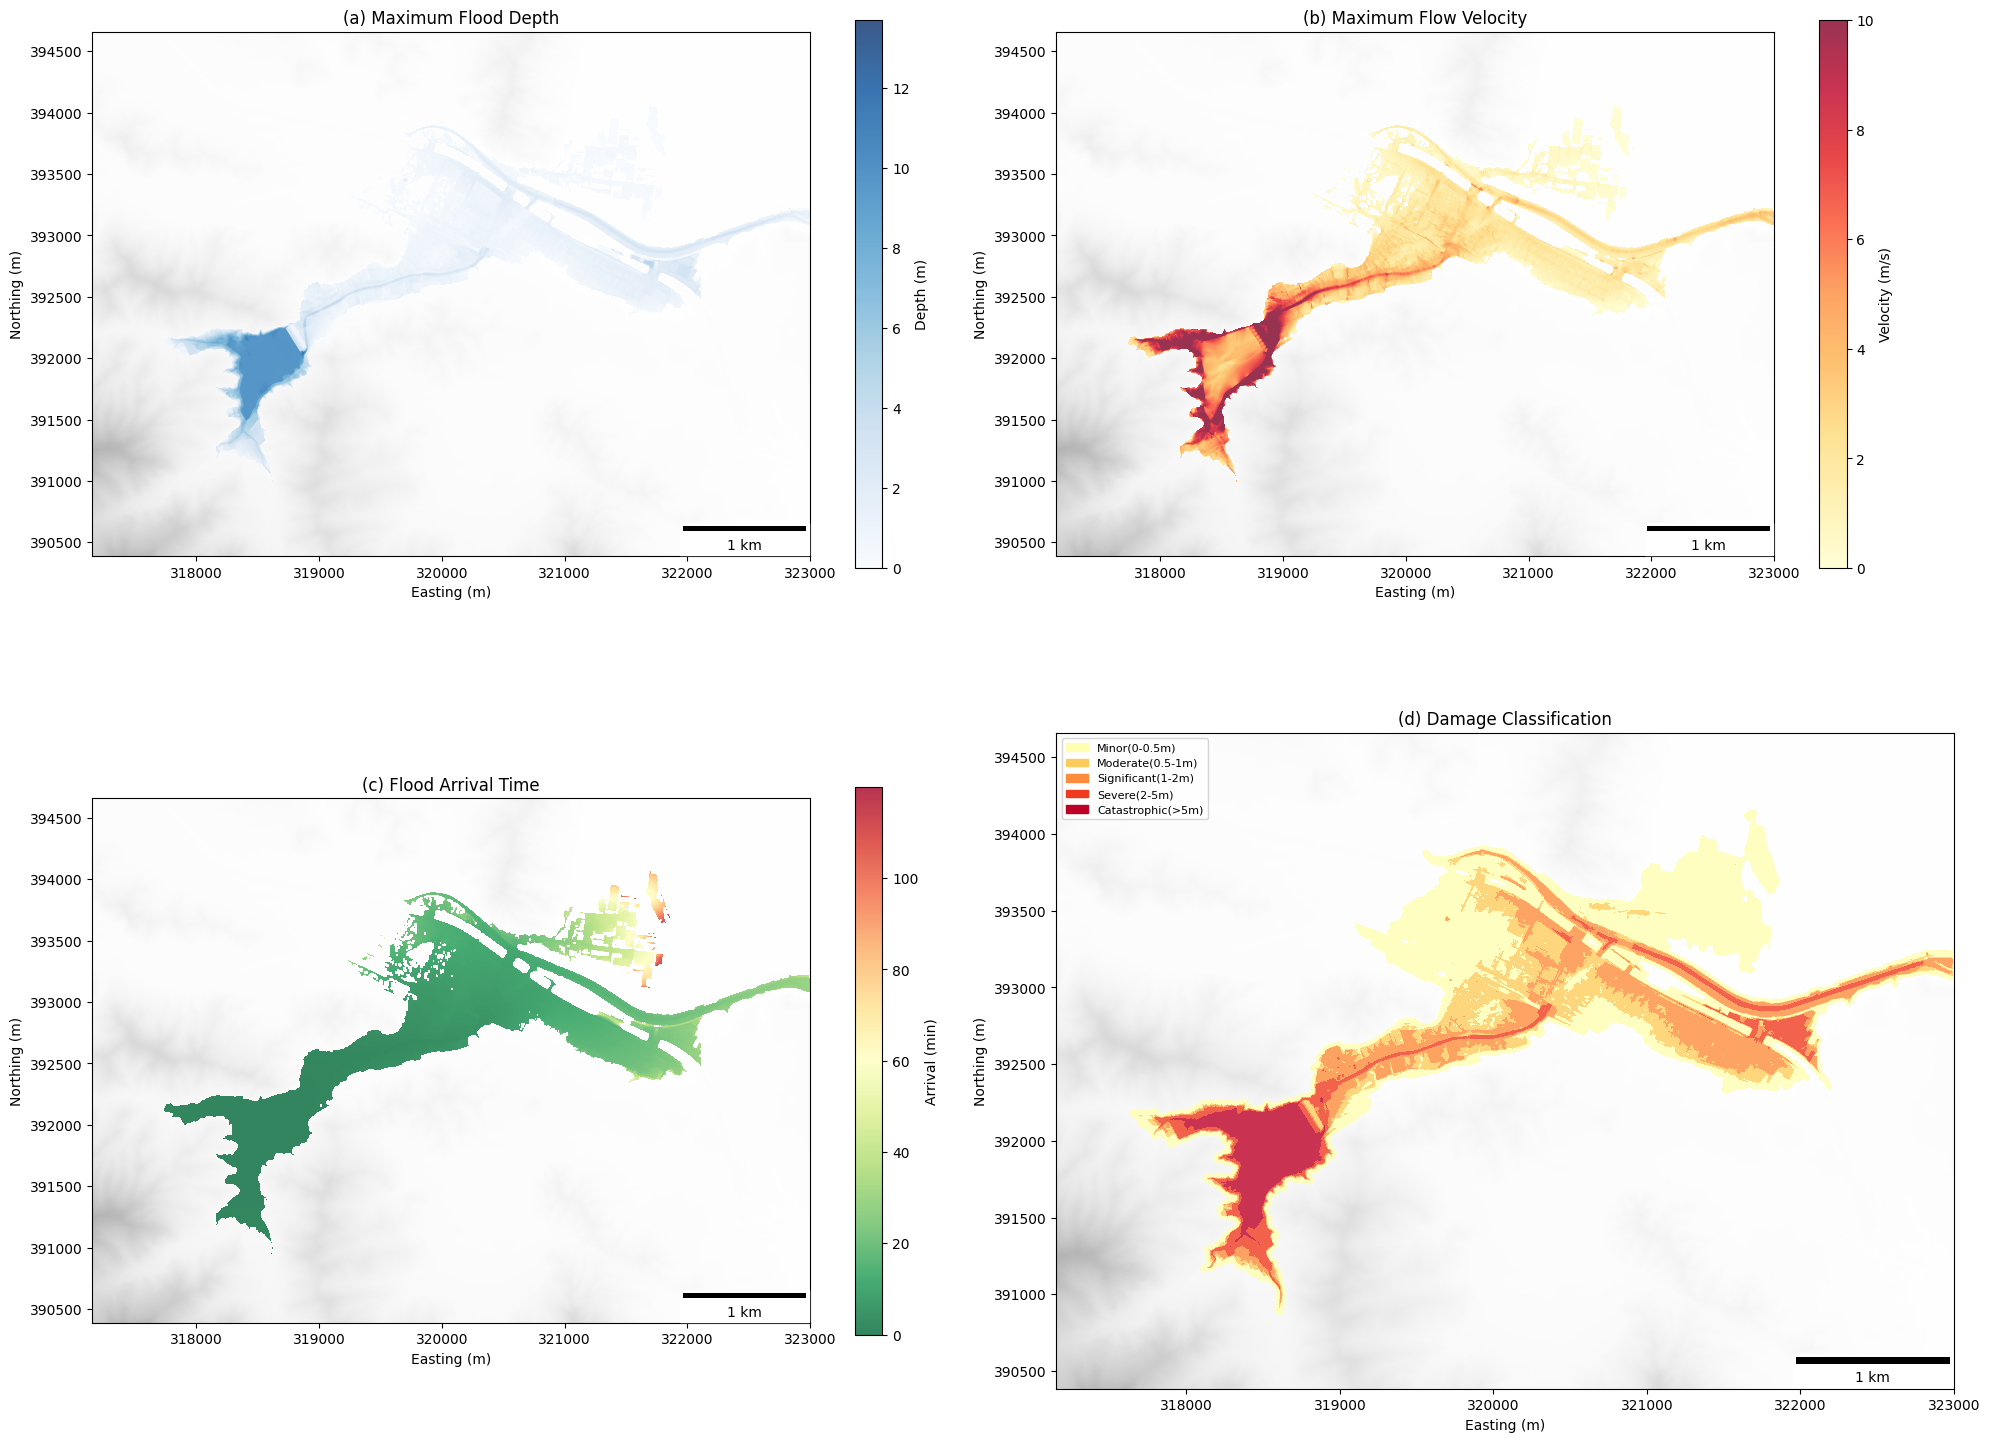

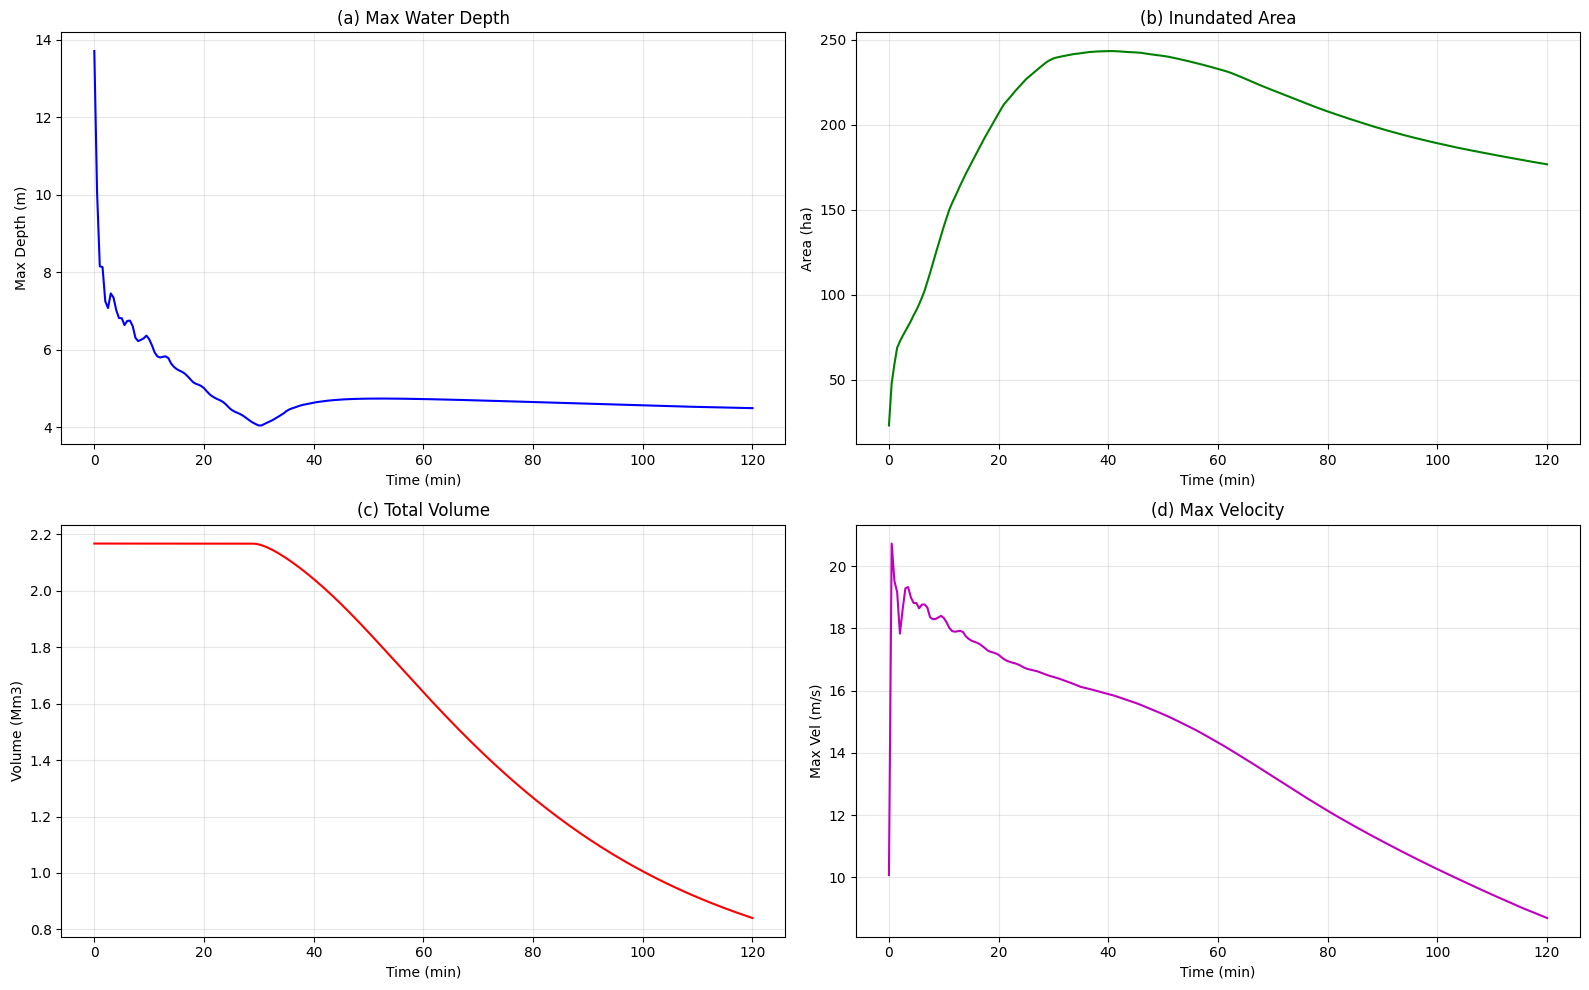

In [11]:
# =============================================================================
# Cell 11: Visualization
# =============================================================================
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

wet_rows, wet_cols = np.where(~np.isnan(max_depth_np))
if len(wet_rows) > 0:
    pad_px = int(500/dx)
    zr1=max(0,wet_rows.min()-pad_px); zr2=min(ny,wet_rows.max()+pad_px)
    zc1=max(0,wet_cols.min()-pad_px); zc2=min(nx,wet_cols.max()+pad_px)
else:
    zr1,zr2,zc1,zc2 = 0,ny,0,nx
zoom = [gt[0]+zc1*dx, gt[0]+zc2*dx, gt[3]-zr2*dy, gt[3]-zr1*dy]
dem_bg = dem_np[zr1:zr2, zc1:zc2].copy()
dem_bg[np.isnan(dem_bg)] = 0

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

ax=axes[0,0]
ax.imshow(dem_bg, cmap='Greys', extent=zoom, alpha=0.3)
im=ax.imshow(max_depth_np[zr1:zr2,zc1:zc2], cmap='Blues', extent=zoom,
             vmin=0, vmax=min(15,np.nanmax(max_depth_np)), alpha=0.8)
plt.colorbar(im, ax=ax, label='Depth (m)', shrink=0.7)
ax.set_title('(a) Maximum Flood Depth'); ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
ax.add_artist(ScaleBar(1, location='lower right'))

ax=axes[0,1]
ax.imshow(dem_bg, cmap='Greys', extent=zoom, alpha=0.3)
im=ax.imshow(max_vel_np[zr1:zr2,zc1:zc2], cmap='YlOrRd', extent=zoom,
             vmin=0, vmax=min(10,np.nanmax(max_vel_np)), alpha=0.8)
plt.colorbar(im, ax=ax, label='Velocity (m/s)', shrink=0.7)
ax.set_title('(b) Maximum Flow Velocity'); ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
ax.add_artist(ScaleBar(1, location='lower right'))

ax=axes[1,0]
ax.imshow(dem_bg, cmap='Greys', extent=zoom, alpha=0.3)
im=ax.imshow(arrival_np[zr1:zr2,zc1:zc2], cmap='RdYlGn_r', extent=zoom,
             vmin=0, vmax=min(120,np.nanmax(arrival_np)), alpha=0.8)
plt.colorbar(im, ax=ax, label='Arrival (min)', shrink=0.7)
ax.set_title('(c) Flood Arrival Time'); ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
ax.add_artist(ScaleBar(1, location='lower right'))

ax=axes[1,1]
ax.imshow(dem_bg, cmap='Greys', extent=zoom, alpha=0.3)
cmap_d = ListedColormap(['#ffffb2','#fecc5c','#fd8d3c','#f03b20','#bd0026'])
norm_d = BoundaryNorm([0.5,1.5,2.5,3.5,4.5,5.5], cmap_d.N)
ax.imshow(damage_class[zr1:zr2,zc1:zc2], cmap=cmap_d, norm=norm_d, extent=zoom, alpha=0.8)
labels_d = ['Minor(0-0.5m)','Moderate(0.5-1m)','Significant(1-2m)','Severe(2-5m)','Catastrophic(>5m)']
patches = [mpatches.Patch(color=cmap_d(i/4), label=labels_d[i]) for i in range(5)]
ax.legend(handles=patches, loc='upper left', fontsize=8)
ax.set_title('(d) Damage Classification'); ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
ax.add_artist(ScaleBar(1, location='lower right'))

plt.tight_layout()
plt.savefig(os.path.join(CONFIG.OUTPUT_DIR,'02_flood_results.png'), dpi=200, bbox_inches='tight')
plt.show()

# Time series
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
tm = [t/60 for t in ts_time]
axes[0,0].plot(tm, ts_maxh, 'b-'); axes[0,0].set_xlabel('Time (min)'); axes[0,0].set_ylabel('Max Depth (m)')
axes[0,0].set_title('(a) Max Water Depth'); axes[0,0].grid(True, alpha=0.3)
axes[0,1].plot(tm, [w*1e6/10000 for w in ts_wet], 'g-'); axes[0,1].set_xlabel('Time (min)')
axes[0,1].set_ylabel('Area (ha)'); axes[0,1].set_title('(b) Inundated Area'); axes[0,1].grid(True, alpha=0.3)
axes[1,0].plot(tm, [v/1e6 for v in ts_vol], 'r-'); axes[1,0].set_xlabel('Time (min)')
axes[1,0].set_ylabel('Volume (Mm3)'); axes[1,0].set_title('(c) Total Volume'); axes[1,0].grid(True, alpha=0.3)
axes[1,1].plot(tm, ts_maxv, 'm-'); axes[1,1].set_xlabel('Time (min)')
axes[1,1].set_ylabel('Max Vel (m/s)'); axes[1,1].set_title('(d) Max Velocity'); axes[1,1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG.OUTPUT_DIR,'03_time_series.png'), dpi=150, bbox_inches='tight')
plt.show()


In [12]:
# =============================================================================
# Cell 12: Export GeoTIFFs
# =============================================================================
from osgeo import gdal, osr

def save_geotiff(fp, data, gt, epsg, nodata=-9999):
    drv = gdal.GetDriverByName('GTiff')
    ds = drv.Create(fp, data.shape[1], data.shape[0], 1, gdal.GDT_Float32,
                    options=['COMPRESS=LZW','TILED=YES'])
    ds.SetGeoTransform(gt)
    srs = osr.SpatialReference(); srs.ImportFromEPSG(epsg)
    ds.SetProjection(srs.ExportToWkt())
    b = ds.GetRasterBand(1); b.SetNoDataValue(nodata)
    out = data.copy(); out[np.isnan(out)] = nodata
    b.WriteArray(out); b.FlushCache(); ds = None
    print(f'  {fp} ({os.path.getsize(fp)/1e6:.1f} MB)')

for name, data in [('max_flood_depth.tif', max_depth_np),
                    ('max_velocity.tif', max_vel_np),
                    ('arrival_time_min.tif', arrival_np),
                    ('damage_class.tif', damage_class)]:
    save_geotiff(os.path.join(CONFIG.OUTPUT_DIR, name), data, gt, CONFIG.EPSG)
print('[OK] GeoTIFFs exported.')


  /home/work/spacenet-data/gumi/output/max_flood_depth.tif (62.8 MB)
  /home/work/spacenet-data/gumi/output/max_velocity.tif (63.7 MB)
  /home/work/spacenet-data/gumi/output/arrival_time_min.tif (53.3 MB)
  /home/work/spacenet-data/gumi/output/damage_class.tif (8.2 MB)
[OK] GeoTIFFs exported.


In [13]:
# =============================================================================
# Cell 13: Save HDF5 archive
# =============================================================================
import h5py

h5p = os.path.join(CONFIG.OUTPUT_DIR, 'geumo_dambreak_results.h5')
with h5py.File(h5p, 'w') as f:
    m = f.create_group('metadata')
    for k in ['FULL_WATER_LEVEL','BOTTOM_LEVEL','MAX_DEPTH','TOTAL_STORAGE',
              'DAM_CREST_ELEV','BREACH_WIDTH','BREACH_TIME','MANNING_N',
              'SIM_DURATION','CFL','MAX_DT']:
        m.attrs[k] = getattr(CONFIG, k)
    m.attrs['dx'] = dx; m.attrs['dy'] = dy; m.attrs['epsg'] = CONFIG.EPSG
    m.attrs['geotransform'] = list(gt)
    f.create_dataset('dem', data=dem_np, compression='gzip', compression_opts=4)
    r = f.create_group('results')
    r.create_dataset('max_depth', data=max_depth_np, compression='gzip')
    r.create_dataset('max_velocity', data=max_vel_np, compression='gzip')
    r.create_dataset('arrival_time', data=arrival_np, compression='gzip')
    r.create_dataset('damage_class', data=damage_class, compression='gzip')
    ts = f.create_group('time_series')
    ts.create_dataset('time_s', data=np.array(ts_time))
    ts.create_dataset('max_depth', data=np.array(ts_maxh))
    ts.create_dataset('wet_area', data=np.array(ts_wet))
    ts.create_dataset('volume', data=np.array(ts_vol))
    ts.create_dataset('max_vel', data=np.array(ts_maxv))
    sg = f.create_group('snapshots')
    si = np.linspace(0, len(snapshots)-1, min(50,len(snapshots)), dtype=int)
    for i in si:
        sg.create_dataset(f't_{snapshots[i]["time"]:.0f}', data=snapshots[i]['h'],
                          compression='gzip', compression_opts=4)
print(f'HDF5: {h5p} ({os.path.getsize(h5p)/1e9:.2f} GB)')


HDF5: /home/work/spacenet-data/gumi/output/geumo_dambreak_results.h5 (3.38 GB)


In [14]:
# =============================================================================
# Cell 14: Final summary
# =============================================================================
print('='*60)
print('  GEUMO RESERVOIR DAM-BREAK SIMULATION RESULTS')
print('='*60)
print(f'  Storage        : {CONFIG.TOTAL_STORAGE:,} m3')
print(f'  Water level    : {CONFIG.FULL_WATER_LEVEL:.2f} EL.m')
print(f'  Max depth      : {np.nanmax(max_depth_np):.2f} m')
print(f'  Max velocity   : {np.nanmax(max_vel_np):.2f} m/s')
print(f'  Inundated area : {np.sum(~np.isnan(max_depth_np))*dx*dy/10000:.2f} ha')
print(f'  Conservation   : {ts_vol[-1]/init_vol*100:.1f}%')
print(f'  Arrival range  : {np.nanmin(arrival_np):.1f} ~ {np.nanmax(arrival_np):.1f} min')
print()
print('[Output Files]')
for fn in sorted(os.listdir(CONFIG.OUTPUT_DIR)):
    fp = os.path.join(CONFIG.OUTPUT_DIR, fn)
    if os.path.isfile(fp):
        sz = os.path.getsize(fp)
        u = 'GB' if sz>1e9 else 'MB' if sz>1e6 else 'KB'
        v = sz/1e9 if sz>1e9 else sz/1e6 if sz>1e6 else sz/1e3
        print(f'  {fn:40s} {v:.1f} {u}')


  GEUMO RESERVOIR DAM-BREAK SIMULATION RESULTS
  Storage        : 2,218,000 m3
  Water level    : 92.30 EL.m
  Max depth      : 13.70 m
  Max velocity   : 22.12 m/s
  Inundated area : 321.91 ha
  Conservation   : 38.8%
  Arrival range  : 0.0 ~ 120.0 min

[Output Files]
  00_corrected_dam_location.png            823.7 KB
  00_dam_location.png                      880.8 KB
  00_final_dam.png                         838.8 KB
  00_polygon_calibration.png               894.6 KB
  00_shoreline_calibration.png             707.6 KB
  01_dem_overview.png                      618.0 KB
  01_reservoir_calibration.png             866.1 KB
  02_flood_results.png                     1.4 MB
  03_time_series.png                       156.7 KB
  arrival_time_min.tif                     53.3 MB
  damage_class.tif                         8.2 MB
  dem_clip.tif                             865.5 MB
  geumo_dambreak_results.h5                3.4 GB
  max_flood_depth.tif                      62.8 MB
  max_velo